# 01 — Introduction to Machine Learning & Deep Learning

**Mathematical Foundations of Control and Machine Learning — Winter 2026**

In this notebook, we build up the core ideas of modern machine learning.

### Table of Contents

1. **What is (supervised) machine learning?** — dataset, model, loss and training
2. **Data** — samples from an unknown distribution; how a word, a graph or a manifold becomes a vector
3. **Models** — linear regression, neural networks, classification outputs
4. **Training** — gradient descent, automatic differentiation and backpropagation, mini-batches
5. **Generalization** — risk vs. empirical risk, train/test splits, underfitting and overfitting, a classifier on held-out data
6. **A zoo of architectures** — MLP, CNN, RNN, transformer, neural ODE

### The mathematics behind machine learning

Machine learning is less a subject of its own than a meeting point. Analysis supplies approximation and the chain rule, linear algebra supplies the operations hardware can execute, probability supplies the very notion of generalization, optimization supplies the training algorithm, and dynamical systems and control supply the language for anything that evolves in time.

![A map of the mathematical fields underlying machine learning](images/math_of_ml.png)

In [1]:
%matplotlib inline
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import plotting as P           # the course palette, the house style, and the figure helpers

# Reproducibility
rng = np.random.default_rng(0)
torch.manual_seed(0);

## 1. What is machine learning?

Every machine learning system, however elaborate, is assembled from three ingredients.

**1. A dataset.** A finite collection of examples

$$\mathcal{D} = \{(x_i, y_i)\}_{i=1}^n$$

of inputs $x_i$ and the outputs $y_i$ we would like to predict. Section 2 says where these examples come from and how an input becomes a vector.

**2. A model.** A parameterized family of functions

$$\mathcal{F} = \{\, f_\theta : \theta \in \Theta \,\}, \qquad f : \mathcal{X} \times \Theta \longrightarrow \mathcal{Y},$$

with parameter space $\Theta \subset \mathbb{R}^P$. Choosing an *architecture* means choosing this family; today $P$ routinely exceeds $10^{9}$.

**3. Training.** A **loss** $\ell(\hat y, y)$ measures how bad the prediction $\hat y$ is when the truth is $y$. Training minimizes the average loss on the data, the **empirical risk**:

$$\hat\theta \;=\; \arg\min_{\theta \in \Theta} \; L(\theta), \qquad L(\theta) = \frac{1}{n} \sum_{i=1}^n \ell\big(f_\theta(x_i), y_i\big).$$

Everything else (architectures, tricks, benchmarks) is an instance of these three. Section 3 makes the model concrete, Section 4 solves the minimization, and Section 5 asks whether a small $L(\hat\theta)$ also means good predictions on data we have not seen.

## 2. Data

**Idea.** Data is a sample from an unknown distribution, encoded as numbers that a model and computer can consume.

### Where data comes from

We model the dataset as independent draws from one fixed but unknown distribution $P$ on $\mathcal{X} \times \mathcal{Y}$:

$$(x_i, y_i) \overset{\text{i.i.d.}}{\sim} P, \qquad i = 1, \dots, n.$$

$P$ is everything there is to know about the task; $\mathcal{D}$ is all we get to see of it. In *unsupervised* learning there are no labels and $\mathcal{D} = \{x_i\}_{i=1}^n$ with $x_i \sim P$.

### Representations

The definition in Section 1 quietly assumed that $x_i$ is a vector. It rarely is. Words, molecules, sounds, images, functions and manifolds are not numbers, yet every model we will write consumes elements of $\mathbb{R}^d$. Something has to bridge the gap: a map

$$\varphi : \{\text{real objects}\} \longrightarrow \mathbb{R}^d,$$

called a **representation** or **embedding**. Here we choose it before training. In other models, the representation is learned jointly with the predictor. Either way, it determines which information the model receives.

![Representations of text, graphs, audio, images, functions and manifolds as vectors](images/representations.png)

**Code and plot.** Build three representations, then plot how Fourier truncation changes a function.

In [2]:
# A word -> a one-hot vector in R^4.
vocab = ["a", "cat", "dog", "sat"]
onehot = np.eye(len(vocab))[vocab.index("cat")]

print("one-hot('cat') =", onehot)

one-hot('cat') = [0. 1. 0. 0.]


In [3]:
# A 4-node graph -> its adjacency matrix in R^{4x4}.
edges = [(0, 1), (0, 2), (1, 2), (2, 3)]
adjacency = np.zeros((4, 4))
for i, j in edges:
    adjacency[i, j] = adjacency[j, i] = 1

print("adjacency =\n", adjacency.astype(int))

adjacency =
 [[0 1 1 0]
 [1 0 1 0]
 [1 1 0 1]
 [0 0 1 0]]


first Fourier coefficients = [1.273 0.    0.424 0.    0.255]


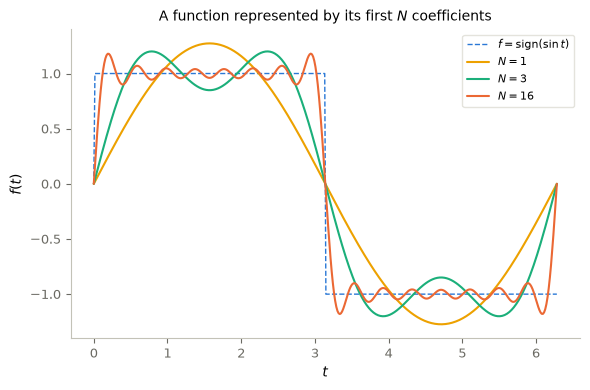

In [4]:
# A function -> its Fourier coefficients.  f(t) = sign(sin t) is odd, so only
# sines appear:  a_k = (1/pi) int_0^{2pi} f(t) sin(kt) dt = 4/(pi k) for k odd.
t_grid = np.linspace(0, 2 * np.pi, 400)
coeffs = np.array([2 * (1 - (-1) ** k) / (np.pi * k) for k in range(1, 17)])
print("first Fourier coefficients =", np.round(coeffs[:5], 3))

# Truncating the coefficient vector to N terms: the representation degrades gracefully.
plt.plot(t_grid, np.sign(np.sin(t_grid)), color=P.BLUE, ls="--", lw=1, label=r"$f = \mathrm{sign}(\sin t)$")
for N, color in [(1, P.YELLOW), (3, P.AQUA), (16, P.ORANGE)]:
    partial = sum(coeffs[k - 1] * np.sin(k * t_grid) for k in range(1, N + 1))
    plt.plot(t_grid, partial, color=color, lw=1.5, label=f"$N = {N}$")
plt.xlabel("$t$"); plt.ylabel("$f(t)$"); plt.legend(fontsize=8)
plt.title(r"A function represented by its first $N$ coefficients")
plt.show()

## 3. Models

**Idea.** A model is a parameterized family of functions; we go from a straight line to a neural network.

### Linear regression

The simplest ansatz: affine functions of a scalar input,

$$f_{w,b}(x) = w x + b, \qquad \mathcal{F} = \{ f_{w,b} : w, b \in \mathbb{R} \},$$

with the **squared loss** $\ell(\hat y, y) = (\hat y - y)^2$. The loss function is the **mean squared error (MSE)**:

$$L(w, b) = \frac{1}{n} \sum_{i=1}^n \big( w x_i + b - y_i \big)^2.$$

Let's generate synthetic data from a "true" line with noise, $y = 2x - 1 + \varepsilon$ with $\varepsilon \sim \mathcal{N}(0, 0.5^2)$:

**Code and plot.** Generate noisy points around a line. Notice which quantities are observed and which are unknown.

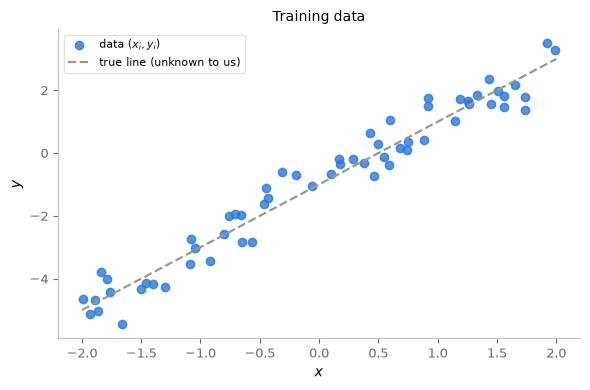

In [5]:
# Ground truth: y = 2x - 1 + noise
w_true, b_true = 2.0, -1.0
n = 60
x = rng.uniform(-2, 2, size=n)
y = w_true * x + b_true + 0.5 * rng.standard_normal(n)

plt.scatter(x, y, color=P.BLUE, alpha=0.8, label="data $(x_i, y_i)$")
plt.plot([-2, 2], [w_true * -2 + b_true, w_true * 2 + b_true],
         color=P.GREY, ls="--", label="true line (unknown to us)")
plt.xlabel("$x$"); plt.ylabel("$y$"); plt.legend(); plt.title("Training data")
plt.show()

### The exact solution

Linear regression is special: $L(w,b)$ is a **convex quadratic**, so we can solve $\nabla L = 0$ in closed form. Stacking the data as $X = \begin{pmatrix} x_1 & 1 \\ \vdots & \vdots \\ x_n & 1\end{pmatrix}$ and $\theta = (w, b)^\top$, the MSE is $L(\theta) = \tfrac1n \lVert X\theta - y \rVert^2$ and setting the gradient to zero gives the **normal equations** (the displayed inverse requires $X$ to have full column rank):

$$X^\top X \, \hat\theta = X^\top y \quad\Longrightarrow\quad \hat\theta = (X^\top X)^{-1} X^\top y.$$

closed form:  w = 1.992,  b = -0.957   (true: w = 2, b = -1)


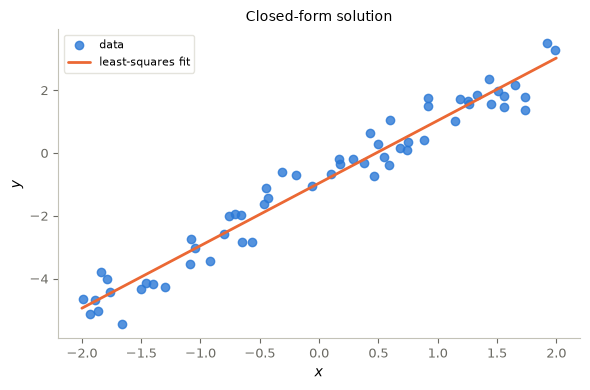

In [6]:
X = np.stack([x, np.ones(n)], axis=1)          # design matrix, shape (n, 2)
theta_hat = np.linalg.solve(X.T @ X, X.T @ y)  # solve the normal equations
w_hat, b_hat = theta_hat
print(f"closed form:  w = {w_hat:.3f},  b = {b_hat:.3f}   (true: w = 2, b = -1)")

xs = np.linspace(-2, 2, 100)
plt.scatter(x, y, color=P.BLUE, alpha=0.8, label="data")
plt.plot(xs, w_hat * xs + b_hat, color=P.ORANGE, lw=2, label="least-squares fit")
plt.xlabel("$x$"); plt.ylabel("$y$"); plt.legend(); plt.title("Closed-form solution")
plt.show()

### Neural networks

Linear models can only represent linear relationships. A **neural network** stacks affine maps with elementwise nonlinearities. The simplest case, a **multilayer perceptron (MLP)** with one hidden layer of width $m$:

$$f_\theta(x) \;=\; W_2 \,\sigma\!\big(W_1 x + b_1\big) + b_2,
\qquad \theta = (W_1, b_1, W_2, b_2),$$

where $\sigma$ is an **activation function** applied componentwise. Without $\sigma$ the composition of affine maps would collapse to a single affine map — the nonlinearity is what buys expressiveness.

**Universal approximation theorem** ([Cybenko, 1989](https://doi.org/10.1007/BF02551274); [Hornik, 1991](https://doi.org/10.1016/0893-6080(91)90009-T); informal): for any continuous $g$ on a compact set and any $\varepsilon > 0$, there is a one-hidden-layer network $f_\theta$ with $\lVert f_\theta - g \rVert_\infty < \varepsilon$, provided the activation satisfies the theorem’s assumptions (for example, a continuous sigmoidal activation) and the width $m$ is large enough. The theorem says such weights *exist* — finding them means minimizing the loss function, which is the subject of Section 4.

**Code and plot.** Plot three activation functions. Notice where each one is nonlinear.

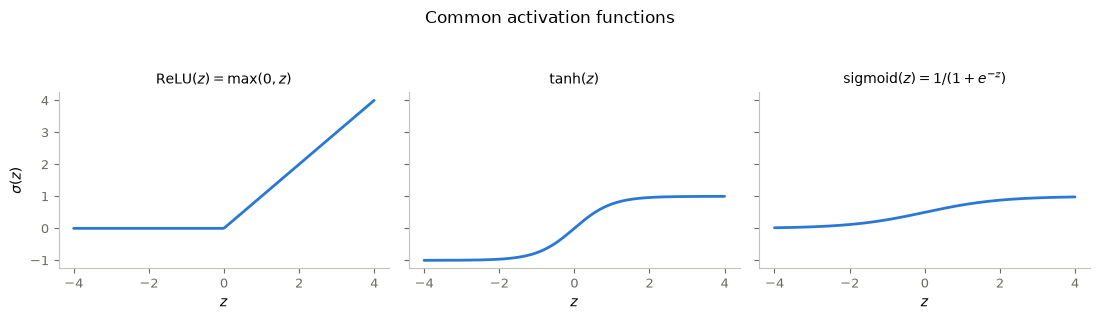

In [7]:
z = torch.linspace(-4, 4, 200)
fig, axes = P.panels(3, size=(3.7, 3.0), sharey=True)
for ax, fn, name in [(axes[0], torch.relu, "ReLU$(z) = \\max(0, z)$"),
                     (axes[1], torch.tanh, "tanh$(z)$"),
                     (axes[2], torch.sigmoid, "sigmoid$(z) = 1/(1+e^{-z})$")]:
    ax.plot(z, fn(z), color=P.BLUE, lw=2)
    P.label(ax, "$z$", title=name)
axes[0].set_ylabel(r"$\sigma(z)$")
fig.suptitle("Common activation functions", y=1.05)
plt.show()

### Classification: logits, softmax and cross-entropy

So far the output $\hat y$ was a real number. For **classification** into $C$ classes the network outputs *logits* $z = f_\theta(x) \in \mathbb{R}^C$, turned into class probabilities by the **softmax**:

$$p_c = \frac{e^{z_c}}{\sum_{c'} e^{z_{c'}}}, \qquad c = 1, \dots, C.$$

The loss is the **cross-entropy**, the negative log-likelihood of the true class:

$$\ell(z, y) = -\log p_y = -z_y + \log \sum_{c} e^{z_c}.$$

Minimizing it is exactly maximum likelihood estimation. Only the last layer and the loss change; the training of Section 4 is the same for both tasks.

## 4. Training

**Idea.** Step against the gradient of the loss, and compute that gradient with the chain rule.

### Gradient descent

For neural networks there is no closed-form solution — but we can always follow the negative gradient downhill. **Gradient descent (GD)** iterates

$$\theta_{k+1} = \theta_k - \eta \, \nabla L(\theta_k),$$

where $\eta > 0$ is the **learning rate** (step size). The gradient points in the direction of steepest *ascent*, so $-\nabla L$ is the direction of steepest *descent*; for small enough $\eta$ each step decreases the loss.

For our linear model the gradient can be computed by hand:

$$\frac{\partial L}{\partial w} = \frac{2}{n}\sum_{i=1}^n \big(w x_i + b - y_i\big)\, x_i,
\qquad
\frac{\partial L}{\partial b} = \frac{2}{n}\sum_{i=1}^n \big(w x_i + b - y_i\big).$$

**Code and plot.** Follow the parameter updates, then compare their path with the loss contours.

In [8]:
def loss(w, b):
    return np.mean((w * x + b - y) ** 2)

def gradient(w, b):
    r = w * x + b - y                      # residuals
    return 2 * np.mean(r * x), 2 * np.mean(r)

# Gradient descent, starting far from the optimum
eta, steps = 0.1, 60
w, b = -1.5, 2.0
path = [(w, b, loss(w, b))]
for k in range(steps):
    gw, gb = gradient(w, b)
    w, b = w - eta * gw, b - eta * gb
    path.append((w, b, loss(w, b)))
path = np.array(path)

print(f"gradient descent:  w = {w:.3f},  b = {b:.3f}")
print(f"closed form:       w = {w_hat:.3f},  b = {b_hat:.3f}")

gradient descent:  w = 1.992,  b = -0.957
closed form:       w = 1.992,  b = -0.957


GD converges to the same solution as the normal equations. Because we have only two parameters, we can *see* the optimization: the loss $L(w, b)$ is a surface over the $(w, b)$-plane, and GD walks downhill on it.

In [9]:
# Loss landscape over the (w, b) plane, and gradient descent walking down it
W, B = np.meshgrid(np.linspace(-2, 4, 120), np.linspace(-2.5, 2.5, 120))
Z = np.array([[loss(wi, bi) for wi in W[0]] for bi in B[:, 0]])

contours = lambda ax: P.contour_path(ax, W, B, Z, optimum=(w_hat, b_hat), optimum_label=r"optimum $\hat\theta$")
P.animate_trajectory(path[:, :2], decorate=contours, figsize=(6.5, 5), equal=False, ticks=True,
                     xlabel="$w$", ylabel="$b$",
                     title=lambda k: rf"Gradient descent on $L(w,b)$: step {k}, $L = {path[k, 2]:.3f}$")

### The learning rate matters

The step size $\eta$ is an important **hyperparameter** in deep learning. For a quadratic loss with a positive-definite Hessian, GD converges from every starting point if and only if $0 < \eta < 2/\lambda_{\max}$, where $\lambda_{\max}$ is the largest eigenvalue of the Hessian $\nabla^2 L$. In practice:

- $\eta$ **too small** → convergence is painfully slow,
- $\eta$ **too large** → the iterates overshoot and oscillate, or even **diverge**.

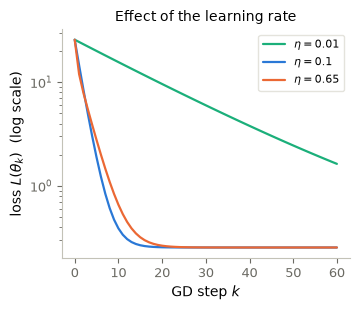

In [10]:
fig, ax = P.panels()
for eta_try, color in [(0.01, P.AQUA), (0.1, P.BLUE), (0.65, P.ORANGE)]:
    w, b = -1.5, 2.0
    losses = [loss(w, b)]
    for k in range(60):
        gw, gb = gradient(w, b)
        w, b = w - eta_try * gw, b - eta_try * gb
        losses.append(loss(w, b))
    ax.semilogy(losses, color=color, label=rf"$\eta = {eta_try}$")
P.label(ax, "GD step $k$", r"loss $L(\theta_k)$  (log scale)", "Effect of the learning rate")
plt.show()

### Automatic differentiation

We computed $\nabla L$ by hand — hopeless for a network with millions of parameters. **Automatic differentiation (autodiff)** solves this: it computes *exact* gradients (up to floating-point error) of any function built from differentiable operations, at roughly the cost of one extra function evaluation.

The idea: every computation is a **graph** of elementary operations, and the chain rule composes their derivatives. For $L = g(h(\theta))$:

$$\frac{\partial L}{\partial \theta} = \frac{\partial g}{\partial h} \cdot \frac{\partial h}{\partial \theta}.$$

**Reverse-mode** autodiff (a.k.a. **backpropagation**) traverses the graph from the output backwards, accumulating these products. One backward pass yields $\partial L / \partial \theta_j$ for **all** parameters $\theta_j$ simultaneously — this is why training huge networks is feasible at all.

In PyTorch: mark a tensor with `requires_grad=True`, compute, then call `.backward()`.

**Code and plot.** Differentiate one scalar function and compare autodiff with an analytic derivative.

In [11]:
# f(x) = sin(x^2) * exp(-x);   analytic derivative: f'(x) = (2x cos(x^2) - sin(x^2)) e^{-x}
x0 = torch.tensor(1.3, requires_grad=True)

f = torch.sin(x0 ** 2) * torch.exp(-x0)   # forward pass (builds the graph)
f.backward()                              # backward pass (chain rule)

analytic = (2 * x0 * torch.cos(x0 ** 2) - torch.sin(x0 ** 2)) * torch.exp(-x0)
h = 1e-5                                  # finite differences, for comparison
def f_np(t): return np.sin(t ** 2) * np.exp(-t)
finite_diff = (f_np(1.3 + h) - f_np(1.3 - h)) / (2 * h)

print(f"autograd:           {x0.grad.item():.10f}")
print(f"analytic:           {analytic.item():.10f}")
print(f"finite differences: {finite_diff:.10f}")

autograd:           -0.3548634648
analytic:           -0.3548634648
finite differences: -0.3548635744


Autodiff is **not** numerical differentiation (no step size $h$, no truncation error) and **not** symbolic differentiation (no expression swell) — it evaluates the chain rule numerically on the graph.

Let's redo linear regression, but now PyTorch computes the gradients:

In [12]:
xt, yt = torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

theta = torch.tensor([-1.5, 2.0], requires_grad=True)   # (w, b), same start as before
eta = 0.1
for k in range(60):
    L = torch.mean((theta[0] * xt + theta[1] - yt) ** 2)
    L.backward()                       # theta.grad now holds dL/dtheta
    with torch.no_grad():              # the update itself is not differentiated
        theta -= eta * theta.grad
    theta.grad.zero_()                 # gradients accumulate -> reset each step

print(f"autograd GD:  w = {theta[0]:.3f},  b = {theta[1]:.3f}")
print(f"closed form:  w = {w_hat:.3f},  b = {b_hat:.3f}")

autograd GD:  w = 1.992,  b = -0.957
closed form:  w = 1.992,  b = -0.957


### Backpropagation: the chain rule on the computational graph

It is worth seeing explicitly what "reverse mode" does on the network of Section 3. Take the two-layer model $f_\theta = \mathcal{A}_2 \circ \sigma \circ \mathcal{A}_1$ with affine maps $\mathcal{A}_\ell(u) = W_\ell u + b_\ell$, and a loss $\mathcal{L} = \ell(\hat y, y)$. The forward pass is a chain:

$$x \in \mathbb{R}^{d} \;\xrightarrow{\ \mathcal{A}_1\ }\; z_1 \in \mathbb{R}^{d_h} \;\xrightarrow{\ \sigma\ }\; h \in \mathbb{R}^{d_h} \;\xrightarrow{\ \mathcal{A}_2\ }\; \hat y \in \mathbb{R}^{d_{\text{out}}} \;\xrightarrow{\ \ell(\cdot,\, y)\ }\; \mathcal{L} \in \mathbb{R}.$$

Reverse-mode autodiff walks this chain backwards, from $\mathcal{L}$ to each parameter:

$$\frac{\partial \mathcal{L}}{\partial W_2}
 = \underbrace{\frac{\partial \mathcal{L}}{\partial \hat y}}_{\text{from } \ell}\,
   \frac{\partial \hat y}{\partial W_2},
\qquad
\frac{\partial \mathcal{L}}{\partial W_1}
 = \frac{\partial \mathcal{L}}{\partial \hat y}\,
   \frac{\partial \hat y}{\partial h}\,
   \frac{\partial h}{\partial z_1}\,
   \frac{\partial z_1}{\partial W_1}.$$

The point is the **shared prefix**. The factor $\partial \mathcal{L}/\partial \hat y$ is computed once and reused by every layer; going one layer deeper appends a single Jacobian-vector product to a quantity that already exists. Because $\mathcal{L}$ is *scalar*, each intermediate derivative has the same shape as the tensor it differentiates. We propagate these derivatives without constructing full Jacobian matrices, so computing the full gradient costs a small multiple of a forward pass.

Forward mode propagates $\partial(\cdot)/\partial\theta_j$ *forwards* instead, and costs one pass **per parameter**. For $f : \mathbb{R}^P \to \mathbb{R}$ with $P$ large, reverse mode wins by a factor of $P$; for $f : \mathbb{R} \to \mathbb{R}^m$ it is the other way round. Training a network is the first case, which is why backpropagation is *the* algorithm of deep learning.

PyTorch records this chain as it runs: every tensor produced by an operation keeps a `grad_fn` pointing back at the operation that made it.

In [13]:
d, d_h, d_out = 3, 4, 2
x_g, y_g = torch.randn(1, d), torch.randn(1, d_out)
W1 = torch.randn(d, d_h, requires_grad=True)
W2 = torch.randn(d_h, d_out, requires_grad=True)

z1 = x_g @ W1                    # A_1
h_g = torch.relu(z1)             # sigma
y_hat = h_g @ W2                 # A_2
Lg = ((y_hat - y_g) ** 2).sum()  # loss

node = Lg.grad_fn                # walk the recorded graph backwards from the loss
while node is not None:
    print("  ", type(node).__name__)
    node = node.next_functions[0][0] if node.next_functions else None

Lg.backward()                    # one pass fills in every gradient
print(f"dL/dW1: {tuple(W1.grad.shape)},  dL/dW2: {tuple(W2.grad.shape)}")

   SumBackward0
   PowBackward0
   SubBackward0
   MmBackward0
   ReluBackward0
   MmBackward0
dL/dW1: (3, 4),  dL/dW2: (4, 2)


### Fitting a nonlinear function

Target: $g(x) = \sin(2\pi x)$ on $[-1, 1]$, observed with noise. We build a small MLP with `nn.Sequential` and train it with the loop that *every* PyTorch training script follows:

```
for each step:  forward pass → loss → zero grads → backward pass → optimizer step
```

Instead of plain GD we use **Adam** ([Kingma and Ba, 2014](https://arxiv.org/abs/1412.6980)), a variant with per-parameter adaptive step sizes (more on optimizers in [notebook 03](03_optimization.ipynb)).

In [14]:
# Noisy samples of g(x) = sin(2*pi*x)
n_reg = 80
x_reg = rng.uniform(-1, 1, size=(n_reg, 1))
y_reg = np.sin(2 * np.pi * x_reg) + 0.1 * rng.standard_normal((n_reg, 1))
xt_reg = torch.tensor(x_reg, dtype=torch.float32)
yt_reg = torch.tensor(y_reg, dtype=torch.float32)

model = nn.Sequential(          # 1 -> 32 -> 32 -> 1 MLP
    nn.Linear(1, 32), nn.Tanh(),
    nn.Linear(32, 32), nn.Tanh(),
    nn.Linear(32, 1),
)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()

xs = torch.linspace(-1, 1, 200).reshape(-1, 1)
snapshots = {}                       # model predictions at a few checkpoints
for epoch in range(2001):
    y_pred = model(xt_reg)           # forward pass
    L = loss_fn(y_pred, yt_reg)      # training loss
    optimizer.zero_grad()            # reset accumulated gradients
    L.backward()                     # backprop
    optimizer.step()                 # parameter update
    if epoch in (0, 100, 500, 2000):
        with torch.no_grad():
            snapshots[epoch] = model(xs).numpy()
        print(f"epoch {epoch:4d}:  MSE = {L.item():.4f}")

epoch    0:  MSE = 0.5687
epoch  100:  MSE = 0.0645


epoch  500:  MSE = 0.0093


epoch 2000:  MSE = 0.0091


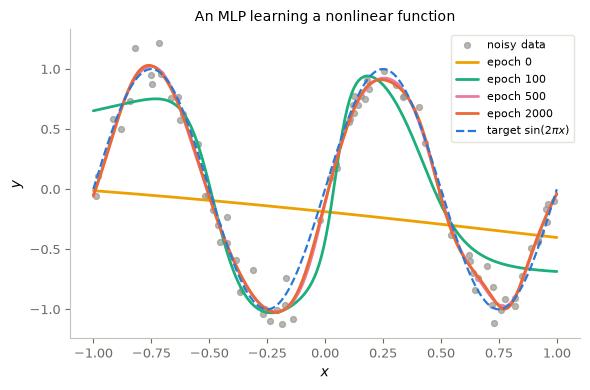

In [15]:
plt.scatter(x_reg, y_reg, color=P.GREY, s=18, alpha=0.7, label="noisy data")
for (epoch, pred), color in zip(snapshots.items(), [P.YELLOW, P.AQUA, P.MAGENTA, P.ORANGE]):
    plt.plot(xs, pred, color=color, lw=2, label=f"epoch {epoch}")
plt.plot(xs, np.sin(2 * np.pi * xs.numpy()), color=P.BLUE, ls="--", label=r"target $\sin(2\pi x)$")
plt.xlabel("$x$"); plt.ylabel("$y$"); plt.legend(fontsize=8)
plt.title("An MLP learning a nonlinear function")
plt.show()

### Mini-batches and stochastic gradients

With large datasets, computing $\nabla L$ over *all* $n$ points per step is wasteful. **Stochastic gradient descent (SGD)** uses a random **mini-batch** $B \subset \{1,\dots,n\}$ per step:

$$\theta_{k+1} = \theta_k - \eta \cdot \frac{1}{|B|} \sum_{i \in B} \nabla_\theta\, \ell\big(f_\theta(x_i), y_i\big),$$

an *unbiased* estimate of the full gradient that is much cheaper — this is what PyTorch's `DataLoader` is for. The price is gradient noise; [notebook 03](03_optimization.ipynb) analyses it.

## 5. Generalization: train / test splits

**Idea.** A good fit to training data must also work on unseen data.

### Risk, and why we cannot minimize it

What we *want* is a small loss on **new** data drawn from the same distribution $P$, that is, a small **risk**

$$R(f) = \mathbb{E}_{(x,y)\sim P}\big[\ell\big(f(x), y\big)\big].$$

But $P$ is unknown, so training minimizes the empirical risk $L$ of Section 1 instead (we write $L(f)$ for $L(\theta)$ when $f = f_\theta$). For a *fixed* $f$, $L(f)$ is an average of $n$ i.i.d. samples of the loss, hence an unbiased estimate of $R(f)$. The trained $\hat f = f_{\hat\theta}$ is not fixed: it was chosen *using* the same data, so this guarantee no longer applies.

| Ingredient | Symbol | Example |
|---|---|---|
| Dataset | $\mathcal{D} = \{(x_i,y_i)\}_{i=1}^n$ | 60 noisy points on a line |
| Model | $\mathcal{F} = \{f_\theta\}_{\theta\in\Theta}$ | affine maps, neural networks |
| Loss | $\ell(\hat y, y)$ | squared error $(\hat y - y)^2$ |
| Risk | $R(f) = \mathbb{E}_P\,[\ell(f(x), y)]$ | what we want, but cannot compute |
| Empirical risk | $L(\theta) = \frac1n\sum_i \ell(f_\theta(x_i), y_i)$ | what we actually minimize |

Replacing $R$ by $L$ is the central bargain of statistical learning. It leaves two questions, which will occupy us for the rest of the course: how to solve $\min_\theta L(\theta)$ in practice (Section 4), and whether a small $L(\hat\theta)$ implies a small $R(\hat\theta)$ (this section). The gap

$$R(\hat f) - L(\hat f)$$

is the **generalization gap**. A model can drive the training loss to zero simply by *memorizing* the data (fitting the noise), while performing terribly on new samples: this is **overfitting**. The opposite failure — an ansatz too weak to capture the signal — is **underfitting**.

We cannot compute $R(\hat f)$ either, but we can *estimate* it on a held-out **test set** that the training procedure never sees. On those points $\hat f$ *is* fixed, so the average below is again an unbiased estimate:

$$R(\hat f) \;\approx\; \frac{1}{n_{\text{test}}} \sum_{i \in \text{test}} \ell\big(\hat f(x_i), y_i\big).$$

### Underfitting and overfitting

The classic demonstration uses polynomial regression: fit polynomials $f(x) = \sum_{j=0}^{d} \theta_j x^j$ of increasing degree $d$ (this is still *linear* in $\theta$, so least squares applies).

**Code and plot.** Fit polynomials of increasing degree and compare training and held-out errors.

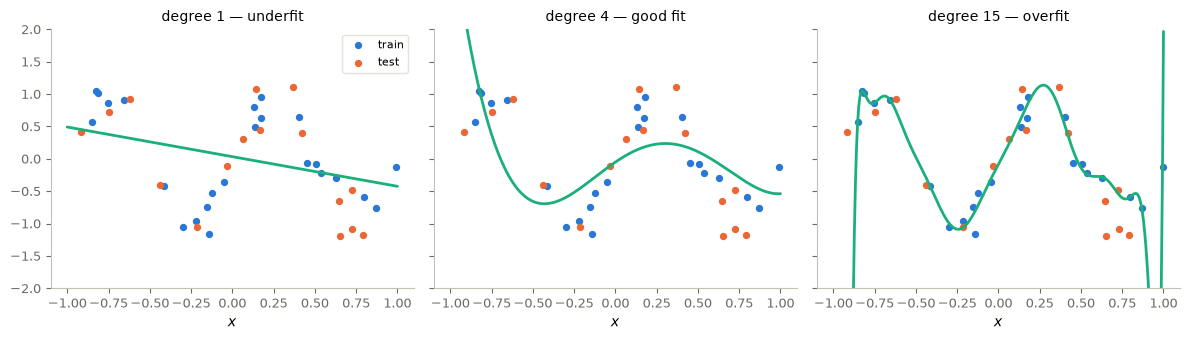

In [16]:
# Noisy samples of a smooth function, split into train and test
n_all = 40
x_all = np.sort(rng.uniform(-1, 1, n_all))
y_all = np.sin(2 * np.pi * x_all) + 0.25 * rng.standard_normal(n_all)
idx = rng.permutation(n_all)
train, test = idx[:24], idx[24:]     # 60% train / 40% test

def polyfit(deg):                    # least squares on the training split
    return np.polynomial.Polynomial.fit(x_all[train], y_all[train], deg)

xs = np.linspace(-1, 1, 300)
fig, axes = P.panels(3, size=(4.0, 3.5), sharey=True)
for ax, deg, note in zip(axes, [1, 4, 15], ["underfit", "good fit", "overfit"]):
    ax.scatter(x_all[train], y_all[train], color=P.BLUE, s=18, label="train")
    ax.scatter(x_all[test], y_all[test], color=P.ORANGE, s=18, label="test")
    ax.plot(xs, polyfit(deg)(xs), color=P.AQUA, lw=2)
    P.label(ax, "$x$", ylim=(-2, 2), title=f"degree {deg} — {note}", legend=ax is axes[0])
plt.show()

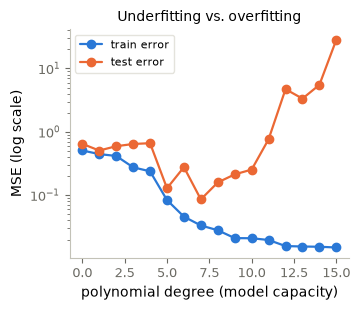

In [17]:
degrees = np.arange(0, 16)
train_err, test_err = [], []
for d in degrees:
    p = polyfit(d)
    train_err.append(np.mean((p(x_all[train]) - y_all[train]) ** 2))
    test_err.append(np.mean((p(x_all[test]) - y_all[test]) ** 2))

fig, ax = P.panels()
P.curves(ax, degrees, {"train error": (train_err, {"color": P.BLUE, "marker": "o"}),
                     "test error": (test_err, {"color": P.ORANGE, "marker": "o"})},
       log="y", xlabel="polynomial degree (model capacity)", ylabel="MSE (log scale)",
       title="Underfitting vs. overfitting")
plt.show()

The plot illustrates a common pattern: **training error decreases** as polynomial degree grows, while **held-out error first falls and then rises**. At first the model captures signal; later it fits noise. This shape is an example, rather than a universal law. Choose the model using *validation* performance and reserve the test set for the final evaluation.

> In practice one uses *three* splits — train / **validation** / test — tuning hyperparameters on the validation set and touching the test set only once, at the very end.

### A classifier on held-out data

The same split applies to a neural network. The "two moons" dataset cannot be separated by any linear model. We train an MLP on 75% of the points with the cross-entropy of Section 3 and the mini-batch SGD of Section 4, and track the accuracy on the remaining 25%, which the training never sees.

**Code and plot.** Plot the two classes, train a small network, and inspect its decision boundary.

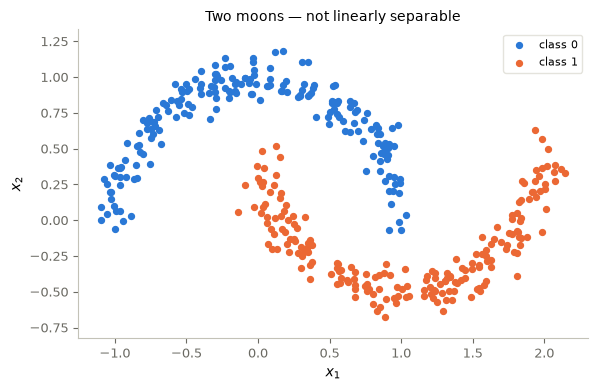

In [18]:
def make_moons(n_per_class=200, noise=0.08):
    t = np.pi * rng.random(n_per_class)
    upper = np.stack([np.cos(t), np.sin(t)], axis=1)             # class 0
    lower = np.stack([1 - np.cos(t), 0.5 - np.sin(t)], axis=1)   # class 1
    X = np.concatenate([upper, lower]) + noise * rng.standard_normal((2 * n_per_class, 2))
    y = np.concatenate([np.zeros(n_per_class), np.ones(n_per_class)]).astype(np.int64)
    return X.astype(np.float32), y

X_moons, y_moons = make_moons()
perm = rng.permutation(len(X_moons))
tr, te = perm[:300], perm[300:]      # 75% train / 25% test

plt.scatter(*X_moons[y_moons == 0].T, color=P.BLUE, s=18, label="class 0")
plt.scatter(*X_moons[y_moons == 1].T, color=P.ORANGE, s=18, label="class 1")
plt.xlabel("$x_1$"); plt.ylabel("$x_2$"); plt.legend(); plt.axis("equal")
plt.title("Two moons — not linearly separable")
plt.show()

In [19]:
from torch.utils.data import DataLoader, TensorDataset

train_set = TensorDataset(torch.tensor(X_moons[tr]), torch.tensor(y_moons[tr]))
loader = DataLoader(train_set, batch_size=32, shuffle=True)
X_test, y_test = torch.tensor(X_moons[te]), torch.tensor(y_moons[te])

clf = nn.Sequential(                 # 2 -> 16 -> 16 -> 2 (logits)
    nn.Linear(2, 16), nn.ReLU(),
    nn.Linear(16, 16), nn.ReLU(),
    nn.Linear(16, 2),
)
optimizer = torch.optim.Adam(clf.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()      # softmax + negative log-likelihood in one

# Grid on which we will visualize the decision boundary
g1, g2 = np.meshgrid(np.linspace(-1.8, 2.8, 120), np.linspace(-1.3, 1.8, 120))
grid = torch.tensor(np.stack([g1.ravel(), g2.ravel()], axis=1), dtype=torch.float32)

history = []
for epoch in range(80):
    for xb, yb in loader:            # one pass over the mini-batches = one epoch
        L = loss_fn(clf(xb), yb)
        optimizer.zero_grad()
        L.backward()
        optimizer.step()
    with torch.no_grad():            # evaluate on held-out data (no gradients needed)
        test_acc = (clf(X_test).argmax(dim=1) == y_test).float().mean().item()
        history.append((L.item(), test_acc))

print(f"final test accuracy: {history[-1][1]:.1%}")

final test accuracy: 100.0%


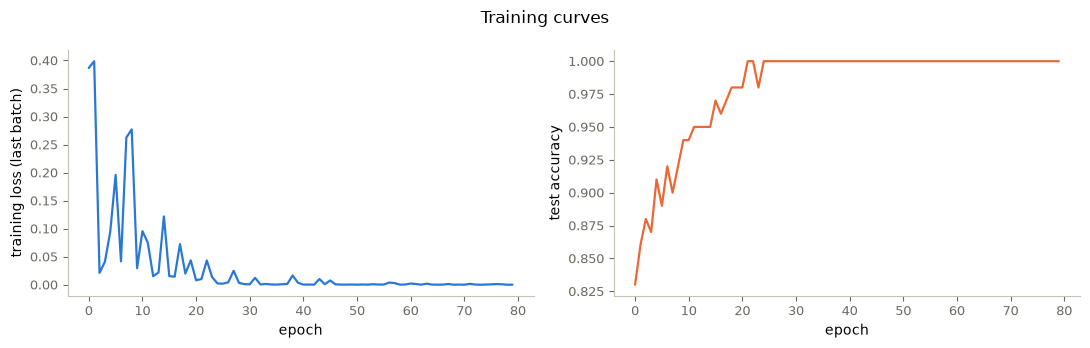

In [20]:
history_arr = np.array(history)
fig, (ax1, ax2) = P.panels(2, size=(5.5, 3.5))
P.curves(ax1, None, history_arr[:, 0], xlabel="epoch", ylabel="training loss (last batch)")
P.curves(ax2, None, (history_arr[:, 1], P.ORANGE), xlabel="epoch", ylabel="test accuracy")
fig.suptitle("Training curves")
plt.show()

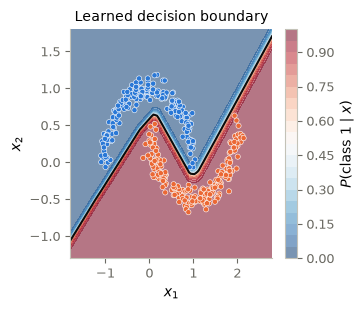

In [21]:
with torch.no_grad():
    probs = torch.softmax(clf(grid), dim=1)[:, 1].reshape(g1.shape).numpy()

fig, ax = P.panels()
P.decision_boundary(ax, g1, g2, probs, X_moons, y_moons, title="Learned decision boundary")
plt.show()

## 6. A zoo of architectures

**Idea.** An architecture builds assumptions about the input into the model.

Changing the architecture changes only the family $\mathcal{F} = \{f_\theta\}$; the dataset, the loss and the training loop stay the same. The standard architectures differ in **which structure of the input they build in**. Below is each one in its smallest form: the defining formula, its assumption, and a shape check in PyTorch.

### 6.1 Multilayer perceptron — no structure assumed

$$f_\theta = \mathcal{A}_L \circ \sigma \circ \cdots \circ \sigma \circ \mathcal{A}_1, \qquad \mathcal{A}_\ell(u) = W_\ell u + b_\ell.$$

The baseline of Section 3. The input is an unstructured vector in $\mathbb{R}^d$: permuting its coordinates (and the columns of $W_1$ with them) gives the same function, so an MLP has no notion of which inputs are *near* one another. It is a universal approximator already at $L = 2$, but the width must grow to make up for the missing structure.

In [22]:
d, d_h, d_out = 16, 32, 4
x_mlp = torch.randn(d)
mlp = nn.Sequential(nn.Linear(d, d_h), nn.ReLU(), nn.Linear(d_h, d_out))

print("MLP        ", tuple(x_mlp.shape), "->", tuple(mlp(x_mlp).shape),
      f"| {sum(p.numel() for p in mlp.parameters())} parameters")

MLP         (16,) -> (4,) | 676 parameters


### 6.2 Convolutional network — translation structure

For an image $x \in \mathbb{R}^{C_{\text{in}} \times H \times W}$ and a $k \times k$ kernel $K$,

$$(K \star x)(i, j) = \sum_{p,\, q} K(p, q)\, x(i - p,\ j - q).$$

The assumption is that **the same local pattern means the same thing wherever it occurs**. Formally, convolution is *translation-equivariant*: $K \star (T_v x) = T_v (K \star x)$ for a shift $T_v$. Hence the parameter count $C_{\text{out}} C_{\text{in}} k^2$ does not depend on the image size, whereas a dense layer needs $C_{\text{in}} H W \times C_{\text{out}} H W$.

In [23]:
x_img = torch.randn(3, 32, 32)                    # one RGB image
conv = nn.Conv2d(3, 8, kernel_size=3)             # 8 output channels
dense_equivalent = (3 * 32 * 32) * (8 * 30 * 30)  # what a fully connected layer would cost

print("CNN        ", tuple(x_img.shape), "->", tuple(conv(x_img).shape),
      f"| {sum(p.numel() for p in conv.parameters())} parameters",
      f"vs {dense_equivalent:,} for a dense layer")

CNN         (3, 32, 32) -> (8, 30, 30) | 224 parameters vs 22,118,400 for a dense layer


### 6.3 Recurrent network — a dynamical system in time

For a sequence $x_1, \dots, x_T$ with $x_t \in \mathbb{R}^{d}$ and hidden state $h_t \in \mathbb{R}^{d_h}$,

$$h_t = \sigma\big(W_h h_{t-1} + W_x x_t + b\big), \qquad \hat y_t = V h_t + c.$$

This is a **discrete dynamical system with a learned vector field**. The same $\theta = (W_h, W_x, V, b, c)$ acts at every step, so one network handles sequences of any length. Training unrolls the recursion (*backpropagation through time*). For $\mathcal{L} = \sum_{t=1}^T \ell(\hat y_t, y_t)$,

$$\frac{\partial \mathcal{L}}{\partial W_h}
 = \sum_{t=1}^{T} \sum_{k=1}^{t}
   \frac{\partial \ell_t}{\partial \hat y_t}\,
   \frac{\partial \hat y_t}{\partial h_t}\,
   \Bigg(\prod_{j=k+1}^{t} \frac{\partial h_j}{\partial h_{j-1}}\Bigg)\,
   \frac{\partial h_k}{\partial W_h}.$$

Each term carries a **product of up to $T$ Jacobians**. It decays geometrically when their norms stay below $1$ (vanishing gradients) and can blow up when they exceed it (exploding gradients). This motivates gated architectures (LSTM, GRU), gradient clipping and, in the continuous limit, the neural ODEs of [notebook 04](04_neuralodes.ipynb).

RNN         (60, 1) -> (60, 8) | 88 parameters, shared over all 60 steps


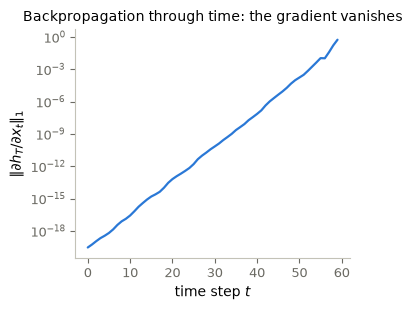

In [24]:
T, d, d_h = 60, 1, 8
rnn = nn.RNN(d, d_h)
xs_seq = torch.randn(T, d, requires_grad=True)
hs, _ = rnn(xs_seq)
hs[-1].sum().backward()           # sensitivity of the LAST state to every input

sensitivity = xs_seq.grad.abs().sum(dim=1)
print("RNN        ", tuple(xs_seq.shape), "->", tuple(hs.shape),
      f"| {sum(p.numel() for p in rnn.parameters())} parameters, shared over all {T} steps")

fig, ax = P.panels()
P.curves(ax, range(T), sensitivity, log="y", xlabel="time step $t$",
       ylabel=r"$\|\partial h_T / \partial x_t\|_1$",
       title="Backpropagation through time: the gradient vanishes")
plt.show()

Read the plot from right to left, the direction the gradient travels. The roughly straight line on the log axis is geometric decay: early inputs receive orders of magnitude less gradient than recent ones, too little to learn from.

### 6.4 Transformer — attention instead of locality

For $T$ tokens stacked as $X \in \mathbb{R}^{T \times d}$, with queries, keys and values $Q = X W_Q$, $K = X W_K$, $V = X W_V$,

$$\mathrm{Attn}(Q, K, V) = \mathrm{softmax}\!\left(\frac{Q K^\top}{\sqrt{d}}\right) V.$$

Each output row is a **convex combination of the value rows**, with weights computed from the data. Unlike a convolution, the neighborhood a token reads from is chosen per input. The map is *permutation-equivariant*, so word order must be injected by positional encodings. Every token reaches every other in one layer, at a cost of $\mathcal{O}(T^2)$ attention weights. [Notebook 06](06_transformers.ipynb) builds this from scratch.

In [25]:
T, d, n_heads = 10, 32, 4
X_tok = torch.randn(T, d)
attn = nn.MultiheadAttention(d, n_heads)
out, weights = attn(X_tok, X_tok, X_tok)   # query = key = value: "self"-attention

print("Transformer", tuple(X_tok.shape), "->", tuple(out.shape),
      f"| attention matrix {tuple(weights.shape)},",
      f"rows sum to {weights.sum(-1).mean():.3f}")

Transformer (10, 32) -> (10, 32) | attention matrix (10, 10), rows sum to 1.000


### 6.5 Neural ODE — depth as continuous time

A residual block $h_{\ell+1} = h_\ell + f_\theta(h_\ell)$ is an explicit Euler step with $\Delta t = 1$. Letting the step size go to zero gives an initial value problem ([Chen et al., 2018](https://arxiv.org/abs/1806.07366)):

$$\frac{d h(t)}{d t} = f_\theta\big(h(t),\, t\big), \qquad h(0) = x, \qquad y = h(T).$$

Depth becomes the integration interval. Under suitable smoothness assumptions the map $x \mapsto h(T)$ is a diffeomorphism, hence invertible. Gradients can be obtained by solving the *adjoint equation* backwards in time, which is Pontryagin's costate from [notebook 07](07_reinforcement_learning.ipynb). This is the bridge between machine learning and control, developed in [notebook 04](04_neuralodes.ipynb).

In [26]:
d, n_steps, T_end = 4, 20, 1.0
field = nn.Sequential(nn.Linear(d, 16), nn.Tanh(), nn.Linear(16, d))   # the vector field f
h_node = torch.randn(d)

dt = T_end / n_steps
for _ in range(n_steps):              # explicit Euler IS the depth of this model
    h_node = h_node + dt * field(h_node)

print("Neural ODE ", (d,), "->", tuple(h_node.shape),
      f"| {sum(p.numel() for p in field.parameters())} parameters for {n_steps} steps",
      "(depth costs no extra parameters)")

Neural ODE  (4,) -> (4,) | 148 parameters for 20 steps (depth costs no extra parameters)


### What they have in common

All five are parameterized families $f_\theta$ trained by the loop of Section 4. What differs is the **inductive bias**, the structure each one assumes about the data:

| Architecture | Assumes | Symmetry | Parameters scale with |
|---|---|---|---|
| MLP | nothing | none | $d \cdot d_h$ |
| CNN | a grid; local patterns recur | translation-equivariant | $C_{\text{out}} C_{\text{in}} k^2$, not image size |
| RNN | a sequence; the update is time-invariant | shared across $t$ | $d_h^2$, not sequence length |
| Transformer | a set of tokens; coupling is data-dependent | permutation-equivariant | $d^2$ per head, not $T$ |
| Neural ODE | continuous evolution | an invertible flow | the vector field, not the number of steps |

Choosing an architecture is choosing what to assume. The assumption *restricts* $\mathcal{F}$. When it matches the data, that restriction is what makes learning from finitely many samples possible.

## Key takeaways

| Concept | Key formula / idea |
|---|---|
| Three ingredients | dataset $\mathcal{D}$, model $\mathcal{F} = \{f_\theta\}$, training $\min_\theta L(\theta)$ |
| Risk vs. empirical risk | $R(f) = \mathbb{E}_P[\ell]$ is what we want; $L(\theta) = \frac1n \sum_i \ell$ is what we minimize |
| Representation | $\varphi:\ \text{object} \to \mathbb{R}^d$; the useful question is what it destroys |
| Neural network (MLP) | $W_2\, \sigma(W_1 x + b_1) + b_2$ — universal approximator |
| Classification | softmax of the logits, cross-entropy $-\log p_y$ = maximum likelihood |
| Gradient descent | $\theta_{k+1} = \theta_k - \eta\, \nabla L(\theta_k)$ |
| Backpropagation | reverse-mode autodiff: all parameter gradients at a small multiple of the forward-pass cost |
| SGD + mini-batches | cheap unbiased gradient estimates via `DataLoader` |
| Training loop | forward → loss → `zero_grad()` → `backward()` → `step()` |
| Generalization | evaluate on held-out data; watch for the U-shaped test error |
| Architecture | a choice of inductive bias: which structure of the data to build in |

## Exercises

1. **Learning rate.** In Section 4, find numerically the largest $\eta$ for which GD still converges. Compare with the theoretical bound $2/\lambda_{\max}(\nabla^2 L)$ — compute the Hessian of the quadratic loss by hand ($\nabla^2 L = \tfrac{2}{n} X^\top X$).
2. **Autodiff.** Use `torch.autograd` to differentiate $f(x) = \log(1 + e^{x})$ at $x = 100$. Explain the result (hint: numerical stability), and compare with `torch.nn.functional.softplus`.
3. **Capacity.** Repeat the two-moons experiment of Section 5 with hidden widths 2, 4, and 64. Plot the three decision boundaries. Which underfits?
4. **Early stopping.** In Section 5, fix the degree at 15 but fit with gradient descent instead of least squares, recording train/test error per iteration. What do you observe about the test error over time?
5. **Regularization.** Add the penalty $\lambda \lVert \theta \rVert^2$ to the degree-15 polynomial *sum of squared errors* (this is *ridge regression*: $\hat\theta = (X^\top X + \lambda I)^{-1} X^\top y$). Sweep $\lambda$ and plot the train/test errors. How does it relate to Exercise 4?
6. **Representation.** For the square wave of Section 2, plot the $L^2$ truncation error $\lVert f - \sum_{k\le N} a_k e_k \rVert$ against $N$ on a log–log scale, and read off the rate. Repeat for the smooth $f(t) = \sin t + \tfrac12 \sin 3t$. Which property of $f$ sets the rate?
7. **Inductive bias.** Flatten a $28 \times 28$ image into a vector and feed it to an MLP; feed the same image to a CNN with a comparable parameter count. Now shift every *test* image by two pixels. Which model degrades, and which sentence of Section 6.2 predicts it?
8. **Vanishing gradients.** In Section 6.3, replace `nn.RNN` by `nn.LSTM` and redraw the sensitivity plot. Over how many steps does the gradient survive now?

## References

**Textbooks and further reading**

- K. P. Murphy, [*Probabilistic Machine Learning: An Introduction*](https://probml.github.io/pml-book/book1.html) (2022) and [*Advanced Topics*](https://probml.github.io/pml-book/book2.html) (2023), MIT Press — the standard modern reference.
- M. Mohri, A. Rostamizadeh, A. Talwalkar, [*Foundations of Machine Learning*](https://cs.nyu.edu/~mohri/mlbook/), 2nd ed., MIT Press, 2018 — the statistical learning theory behind Section 5.
- C. M. Bishop, [*Pattern Recognition and Machine Learning*](https://www.microsoft.com/en-us/research/publication/pattern-recognition-machine-learning/), Springer, 2006.
- I. Goodfellow, Y. Bengio, A. Courville, [*Deep Learning*](https://www.deeplearningbook.org/), MIT Press, 2016 — the architectures of Section 6.
- A. Zhang, Z. C. Lipton, M. Li, A. J. Smola, [*Dive into Deep Learning*](https://d2l.ai/) — free and code-first.
- P. Lippe, [*UvA Deep Learning Tutorials*](https://uvadlc-notebooks.readthedocs.io/en/latest/) — PyTorch notebooks.

**Papers cited in the text**

- G. Cybenko, [*Approximation by superpositions of a sigmoidal function*](https://doi.org/10.1007/BF02551274), 1989.
- K. Hornik, [*Approximation capabilities of multilayer feedforward networks*](https://doi.org/10.1016/0893-6080(91)90009-T), 1991.
- D. P. Kingma and J. Ba, [*Adam: A method for stochastic optimization*](https://arxiv.org/abs/1412.6980), 2014 preprint; ICLR, 2015.
- Y. N. Dauphin et al., [*Identifying and attacking the saddle point problem in high-dimensional non-convex optimization*](https://arxiv.org/abs/1406.2572), NeurIPS, 2014.
- A. Choromanska et al., [*The loss surfaces of multilayer networks*](https://arxiv.org/abs/1412.0233), AISTATS, 2015.
- A. Jacot, F. Gabriel and C. Hongler, [*Neural tangent kernel: convergence and generalization in neural networks*](https://arxiv.org/abs/1806.07572), NeurIPS, 2018.
- M. Belkin et al., [*Reconciling modern machine-learning practice and the classical bias–variance trade-off*](https://doi.org/10.1073/pnas.1903070116), PNAS, 2019.
- R. T. Q. Chen et al., [*Neural ordinary differential equations*](https://arxiv.org/abs/1806.07366), NeurIPS, 2018.
